[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/calculus/09_taylor_and_power_series/first_principles.ipynb)

# Module 09 — Taylor and Power Series

## 1. Why This Module Exists

A computer can add and multiply. It cannot evaluate $\sin$, $\exp$ or $\ln$. Every value of
those functions that a machine has ever printed came from a polynomial.

Polynomials are the only functions a finite arithmetic unit can evaluate exactly, so the
practical question is not *whether* to replace a smooth function by a polynomial but **how large
the replacement error is, and on what interval it stays small**.

This module answers that in two stages. First, for a fixed degree: Taylor's theorem writes the
error as one explicit term, in three interchangeable forms, each of which converts a bound on a
derivative into a bound on the error.

Second, in the limit of infinite degree: a power series either converges on a symmetric interval
or nowhere but at its centre, the radius is computed by one formula, and inside that radius the
series may be differentiated and integrated term by term — the single fact that makes power
series a working calculus rather than a formal one.

The last point is the theorem this module is named after, and it is the one that is usually
asserted. It is proved here in full, from uniform convergence, in Proof 5.7.

## 2. Intuition

Fix a smooth $f$ and a point $a$. The tangent line at $a$ is the unique degree-$1$ polynomial
that touches $f$ in value and slope.

Raising the degree adds one more matched derivative each time. The degree-$n$ polynomial agrees
with $f$ in value and in the first $n$ derivatives at $a$ — it has **contact of order $n$**.

The picture to hold is a family of curves that hug $f$ ever more tightly near $a$ and then peel
away. Each new degree buys a wider window at a fixed accuracy, not accuracy everywhere.

Whether the window eventually covers the whole line is a separate question, and its answer is
invisible from the real graph. The series for $1/(1+x^2)$ stops converging at $x = \pm 1$ even
though the function is perfectly smooth there, because the *complex* function has poles at
$\pm i$, at distance $1$ from the centre.

So there are two independent things to control: how fast the error falls as the degree grows,
and how far from $a$ the process works at all. The first is the remainder theorems; the second
is the radius of convergence.

The first code cell is the notebook preamble. It fixes plotting defaults, seeds the single
random generator used in this notebook, and prints the machine epsilon that later residual
claims are measured against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

EPS = np.finfo(float).eps
print(f"machine epsilon = {EPS:.4e}")

machine epsilon = 2.2204e-16


Every residual reported below is quoted as a multiple of this number.

The next cell draws the picture described above: the odd-degree Maclaurin polynomials
$P_1, P_3, P_5, P_7$ of $\sin$ against $\sin$ itself on $[-\pi, \pi]$, together with the width of
the window on which each stays within $10^{-2}$ of the true value.

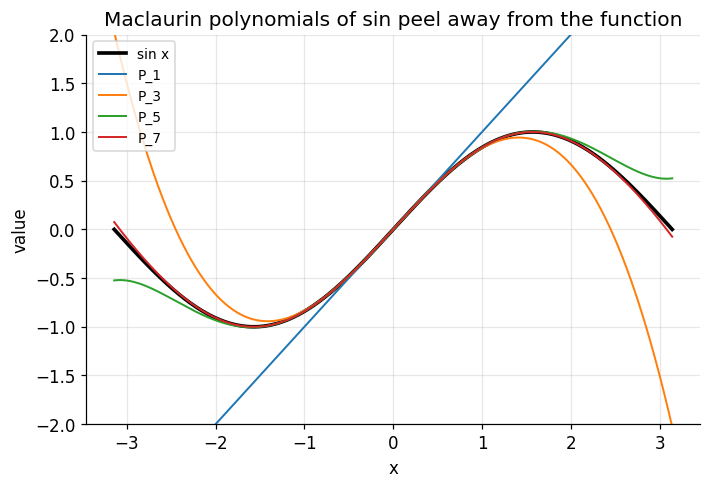

half-width of the window where |sin x - P_n(x)| <= 1e-2
  n = 1:  |x| <= 0.3848
  n = 3:  |x| <= 1.0367
  n = 5:  |x| <= 1.7593
  n = 7:  |x| <= 2.4976


In [2]:
from math import factorial


def maclaurin_sin(x, n):
    """Degree-n Maclaurin polynomial of sin, by explicit summation of the odd terms."""
    total = np.zeros_like(np.asarray(x, dtype=float))
    j = 0
    while 2 * j + 1 <= n:
        k = 2 * j + 1
        total = total + (-1.0) ** j * x ** k / factorial(k)
        j += 1
    return total


xs = np.linspace(-np.pi, np.pi, 801)
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(xs, np.sin(xs), lw=2.4, color="k", label="sin x")
for n in (1, 3, 5, 7):
    ax.plot(xs, maclaurin_sin(xs, n), lw=1.3, label=f"P_{n}")
ax.set_ylim(-2.0, 2.0)
ax.set_xlabel("x")
ax.set_ylabel("value")
ax.set_title("Maclaurin polynomials of sin peel away from the function")
ax.legend(loc="upper left", fontsize=9)
plt.show()

print("half-width of the window where |sin x - P_n(x)| <= 1e-2")
for n in (1, 3, 5, 7):
    err = np.abs(np.sin(xs) - maclaurin_sin(xs, n))
    ok = np.abs(xs[err <= 1e-2])
    print(f"  n = {n}:  |x| <= {ok.max():.4f}")

Each curve is indistinguishable from $\sin$ near the origin and then leaves it. The window in
which the error stays below $10^{-2}$ widens from $\lvert x \rvert \le 0.385$ at degree $1$ to
$\lvert x \rvert \le 2.498$ at degree $7$: raising the degree buys width, not global accuracy.

## 3. Definitions

Throughout, $I \subseteq \mathbb{R}$ is an open interval, $a \in I$, and $f^{(k)}$ is the $k$-th
derivative of $f$, with $f^{(0)} = f$.

Symbols follow [the notation register](../../docs/notation.md). Two rulings matter here: the
Taylor polynomial is $P_n$ with remainder $R_n$, never $T_n$ (which is reserved for Chebyshev),
and asymptotic symbols are the bare capitals $O$ and $o$.

### Definition 3.1 — Taylor polynomial and remainder

Let $f$ be $n$ times differentiable at $a$. The **degree-$n$ Taylor polynomial of $f$ at $a$** is

$$
P_n(x) = \sum_{k=0}^{n} \frac{f^{(k)}(a)}{k!} (x-a)^k .
$$

It is the unique polynomial of degree at most $n$ with $P_n^{(k)}(a) = f^{(k)}(a)$ for
$k = 0, 1, \dots, n$, because differentiating $\sum_k c_k (x-a)^k$ exactly $k$ times and setting
$x = a$ leaves $k!\,c_k$.

The **remainder** is the error it commits:

$$
R_n(x) = f(x) - P_n(x) .
$$

When $a = 0$ the polynomial is also called the Maclaurin polynomial. This module writes $P_n$ in
both cases and names the centre explicitly.

### Definition 3.2 — Power series and radius of convergence

A **power series centred at $a$** is a formal expression

$$
\sum_{n=0}^{\infty} a_n (x-a)^n , \qquad a_n \in \mathbb{R} \text{ or } \mathbb{C} .
$$

Its **radius of convergence** is

$$
R = \sup \Bigl\{ r \ge 0 : \textstyle\sum_n \lvert a_n \rvert r^n \lt \infty \Bigr\} \in [0, \infty] .
$$

The open interval $(a-R, a+R)$ is the **interval of convergence**; behaviour at the two endpoints
is not determined by $R$ and must be examined separately.

### Definition 3.3 — Limit superior

For a real sequence $(b_n)$ bounded above,

$$
\limsup_{n \to \infty} b_n = \lim_{N \to \infty} \ \sup_{n \ge N} b_n ,
$$

the limit of a non-increasing sequence, hence always defined in $[-\infty, +\infty]$. If
$(b_n)$ is unbounded above the value is $+\infty$.

The property used below is the only one needed: for every $\varepsilon \gt 0$ there are
**finitely many** $n$ with $b_n \gt L + \varepsilon$ and **infinitely many** $n$ with
$b_n \gt L - \varepsilon$, where $L = \limsup_n b_n$ is finite.

The limit superior replaces the limit because $\lvert a_n \rvert^{1/n}$ need not converge: the
series of Example 6.3 has $\lvert a_n \rvert^{1/n}$ alternating between $2$ and $3$ forever.

### Definition 3.4 — Pointwise and uniform convergence

Let $g_N, g$ be functions on a set $S$. The sequence $g_N$ converges to $g$

- **pointwise** on $S$ if $g_N(x) \to g(x)$ for each fixed $x \in S$;
- **uniformly** on $S$ if $\displaystyle \sup_{x \in S} \lvert g_N(x) - g(x) \rvert \to 0$.

A series $\sum_n u_n$ converges uniformly on $S$ when its partial sums do.

The distinction is the whole content of Section 5: uniform convergence is what licenses
exchanging a limit with an integral or a derivative, and pointwise convergence does not.

### Definition 3.5 — Smooth and analytic

$f$ is **smooth**, written $f \in C^{\infty}(I)$, if $f^{(k)}$ exists and is continuous on $I$
for every $k \ge 0$.

$f$ is **analytic at $a$** if there is $\rho \gt 0$ and a power series with

$$
f(x) = \sum_{n=0}^{\infty} a_n (x-a)^n \qquad \text{for all } \lvert x - a \rvert \lt \rho .
$$

Analytic implies smooth, by Theorem 4.7. The converse is false, by Proposition 4.10.

### Definition 3.6 — The symbols $O$ and $o$

For $x \to a$, write

- $f(x) = O(g(x))$ if there are $M \gt 0$ and $\delta \gt 0$ with
  $\lvert f(x) \rvert \le M \lvert g(x) \rvert$ whenever $0 \lt \lvert x-a \rvert \lt \delta$;
- $f(x) = o(g(x))$ if $f(x)/g(x) \to 0$ as $x \to a$.

Both are statements about a *set* of functions; the equals sign is one-directional. As $x \to 0$
the rules used below are $O(x^m) + O(x^n) = O(x^{\min(m,n)})$, $O(x^m)\,O(x^n) = O(x^{m+n})$ and
$x^k O(x^m) = O(x^{m+k})$.

## 4. Main Results

Theorems 4.1 to 4.4 are one theorem in four costumes: they all say $f = P_n + R_n$ and differ
only in how $R_n$ is presented and in what they demand of $f$.

Theorems 4.5 to 4.9 are the power-series half. Theorem 4.7 is the result the module is named
after and everything in Sections 4.5 and 4.6 exists to make its proof possible.

### Theorem 4.1 — Taylor's theorem, integral remainder

Let $f$ be $n+1$ times differentiable on an open interval $I$ containing $a$ and $x$, with
$f^{(n+1)}$ continuous on the closed interval between $a$ and $x$. Then

$$
R_n(x) = \frac{1}{n!} \int_{a}^{x} f^{(n+1)}(t)\, (x-t)^n \, dt .
$$

**Hypotheses.** Continuity of $f^{(n+1)}$ is needed only so the integral exists as a Riemann
integral; it is the strongest hypothesis of the four theorems and buys the strongest conclusion,
an exact identity with no unknown point in it.

Proved as Proof 5.1.

### Theorem 4.2 — Taylor's theorem, Lagrange remainder

Let $f^{(n)}$ be continuous on the closed interval between $a$ and $x$ and let $f^{(n+1)}$ exist
on the open interval between them. Then there is a point $c$ strictly between $a$ and $x$ with

$$
R_n(x) = \frac{f^{(n+1)}(c)}{(n+1)!} (x-a)^{n+1} .
$$

**Hypotheses.** Differentiability of order $n+1$ is needed on the open interval only, and no
continuity of $f^{(n+1)}$ is required — this is what makes Lagrange weaker in hypothesis than
Theorem 4.1. The conclusion is correspondingly weaker: $c$ is not computable, only bounded.

**Real-valuedness is essential.** The proof runs through a mean-value theorem, which fails for
complex-valued and vector-valued functions. Section 7.3 exhibits an $f : \mathbb{R} \to \mathbb{C}$
for which no such $c$ exists at any $n$.

Proved as Proof 5.2.

### Theorem 4.3 — Taylor's theorem, Cauchy remainder

Under the hypotheses of Theorem 4.2 there is a point $c$ strictly between $a$ and $x$ with

$$
R_n(x) = \frac{f^{(n+1)}(c)}{n!} (x-c)^n (x-a) .
$$

**Hypotheses.** Identical to Theorem 4.2; only the auxiliary function in the proof changes. The
point $c$ is a different point in general.

**Why a second form.** The factor $(x-c)^n$ can be compared with $(1+c)^n$ in the denominator of
$f^{(n+1)}(c)$, which is exactly what the binomial series needs near $x = -1$ and what the
Lagrange form cannot supply. Exercise L1.10 is that computation.

Proved as Proof 5.3.

### Theorem 4.4 — Taylor's theorem, Peano remainder

Let $f$ be $n$ times differentiable at $a$ — nothing more. Then

$$
R_n(x) = o\bigl( (x-a)^n \bigr) \qquad \text{as } x \to a ,
$$

equivalently $\lim_{x \to a} R_n(x) / (x-a)^n = 0$.

**Hypotheses.** The weakest of the four: only the $n$-th derivative **at the single point $a$**.
The conclusion is purely local and carries no numerical bound at any fixed $x$; Exercise L0.1
contrasts the two.

Proved as Proof 5.4.

### Theorem 4.5 — Cauchy-Hadamard

For a power series $\sum_n a_n (x-a)^n$ put

$$
L = \limsup_{n \to \infty} \lvert a_n \rvert^{1/n} \in [0, \infty] .
$$

Then the radius of convergence of Definition 3.2 is

$$
R = \frac{1}{L},
$$

with the conventions $1/0 = \infty$ and $1/\infty = 0$. The series converges absolutely for
$\lvert x - a \rvert \lt R$ and diverges for $\lvert x - a \rvert \gt R$.

**Hypotheses.** None whatsoever: every power series has a radius, and the formula always applies.
The ratio $\lvert a_{n+1}/a_n \rvert$ gives the same answer **only when that limit exists**, which
is why $\limsup$ and not $\lim$ appears; Example 6.3 is a series where the ratio oscillates
between $0$ and $\infty$ while $R = 1/3$.

Proved as Proof 5.5.

### Theorem 4.6 — Weierstrass M-test, and uniform convergence on compact subintervals

**M-test.** Let $u_n : S \to \mathbb{R}$ satisfy $\sup_{x \in S} \lvert u_n(x) \rvert \le M_n$ with
$\sum_n M_n \lt \infty$. Then $\sum_n u_n$ converges absolutely and uniformly on $S$.

**Consequence for power series.** If $\sum_n a_n (x-a)^n$ has radius $R \gt 0$ then for every
$r \lt R$ the series converges uniformly on the compact interval $[a-r, a+r]$.

**Hypotheses.** The bounds $M_n$ must not depend on $x$; that is the entire content of the word
*uniform*. Uniformity holds on every compact subinterval but in general **not** on the full open
interval: for $\sum_n x^n$ on $(-1,1)$ the supremum of the tail after $N$ terms is infinite for
every $N$.

Proved as Proof 5.6.

### Theorem 4.7 — Term-by-term differentiation and integration

Let $\sum_n a_n (x-a)^n$ have radius of convergence $R \gt 0$ and set
$f(x) = \sum_n a_n(x-a)^n$ on $(a-R, a+R)$.

Then $f$ is differentiable on $(a-R, a+R)$,

$$
f'(x) = \sum_{n=1}^{\infty} n\, a_n (x-a)^{n-1},
$$

and this differentiated series has radius of convergence exactly $R$.

Consequently $f \in C^{\infty}(a-R, a+R)$, and integration is likewise term by term:

$$
\int_{a}^{x} f(t)\,dt = \sum_{n=0}^{\infty} \frac{a_n}{n+1} (x-a)^{n+1}, \qquad \lvert x-a \rvert \lt R .
$$

**Hypotheses.** $R \gt 0$, and $x$ strictly inside the interval. Both are needed. The endpoint is
genuinely excluded: $\sum_n x^n / n$ converges at $x = -1$ while its derivative series
$\sum_n x^{n-1}$ diverges there, a case run in Section 7.3.

**This is the theorem the module is named after.** It is what turns a power series from a formal
object into a function one can do calculus with, and it is proved in full — not sketched — as
Proof 5.7.

### Corollary 4.8 — Coefficients are unique, and are Taylor coefficients

If $\sum_n a_n (x-a)^n$ has radius $R \gt 0$ and sum $f$, then

$$
a_n = \frac{f^{(n)}(a)}{n!} \qquad \text{for every } n \ge 0 .
$$

Hence two power series about the same centre that agree on any interval around it have identical
coefficients, and a function analytic at $a$ has exactly one power-series representation there —
its Taylor series.

Proved as Proof 5.8.

### Theorem 4.9 — Abel's limit theorem

Let $\sum_n a_n$ converge, and put $f(x) = \sum_n a_n x^n$ for $\lvert x \rvert \lt 1$. Then

$$
\lim_{x \to 1^{-}} f(x) = \sum_{n=0}^{\infty} a_n .
$$

**Hypotheses.** Only convergence of the numerical series $\sum_n a_n$ — not absolute convergence.
That is exactly what makes the theorem useful: the interesting endpoint sums, $\ln 2$ and
$\pi/4$, are conditional.

**The converse fails.** $\sum_n (-1)^n$ has $f(x) = 1/(1+x) \to 1/2$ while the series diverges,
so existence of the limit does not recover convergence without an extra hypothesis on $a_n$
(a Tauberian condition).

Proved as Proof 5.9.

### Proposition 4.10 — Smooth does not imply analytic

Define

$$
f(x) = \begin{cases} e^{-1/x^2}, & x \neq 0 \\ 0, & x = 0 . \end{cases}
$$

Then $f \in C^{\infty}(\mathbb{R})$ and $f^{(n)}(0) = 0$ for every $n \ge 0$.

Its Taylor series at $0$ is identically zero and converges everywhere, yet it equals $f$ only at
the single point $x = 0$.

**Consequence.** $R_n(x) \not\to 0$ as $n \to \infty$: the remainder is the whole function. A
convergent Taylor series is no evidence that it converges *to the function it came from*, and
that gap is exactly what Theorems 4.1 to 4.3 are for.

Proved as Proof 5.10.

### Theorem 4.11 (cited, not proved here) — Borel's theorem

For **every** sequence $(c_n)$ of real numbers there exists $f \in C^{\infty}(\mathbb{R})$ with
$f^{(n)}(0) = n!\, c_n$ for all $n$.

So the map from smooth functions to formal power series is onto: no growth condition on the
Taylor coefficients of a smooth function exists at all, and Proposition 4.10 is the mildest case
of a completely general phenomenon.

The proof needs a smooth partition of unity and a convergence argument on the tails, which is
outside the tools developed here. Source: Hörmander, *The Analysis of Linear Partial Differential
Operators I*, 2nd ed., Theorem 1.2.6.

Exercise L3.6 proves in full the strongest special case this module supports: an explicit smooth
function whose Maclaurin series has radius of convergence $0$.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1, integral remainder)

By induction on $n$.

**Base case $n = 0$.** The fundamental theorem of calculus gives

$$
f(x) - f(a) = \int_{a}^{x} f'(t)\,dt ,
$$

and $P_0(x) = f(a)$, so $R_0(x) = \frac{1}{0!}\int_a^x f'(t)(x-t)^0\,dt$ as claimed.

**Inductive step.** Assume the formula at index $n-1$:

$$
R_{n-1}(x) = \frac{1}{(n-1)!} \int_{a}^{x} f^{(n)}(t)\,(x-t)^{n-1}\,dt .
$$

Integrate by parts in $t$, with $u = f^{(n)}(t)$ and $dv = (x-t)^{n-1}dt$, so that
$v = -(x-t)^n / n$:

$$
\int_{a}^{x} f^{(n)}(t)(x-t)^{n-1}dt
= \Bigl[ -f^{(n)}(t)\frac{(x-t)^n}{n} \Bigr]_{t=a}^{t=x}
+ \frac{1}{n}\int_{a}^{x} f^{(n+1)}(t)(x-t)^{n}dt .
$$

The bracket vanishes at $t = x$ and contributes $+f^{(n)}(a)(x-a)^n / n$ at $t = a$. Dividing by
$(n-1)!$,

$$
R_{n-1}(x) = \frac{f^{(n)}(a)}{n!}(x-a)^n + \frac{1}{n!}\int_{a}^{x} f^{(n+1)}(t)(x-t)^n dt .
$$

The first term is exactly the degree-$n$ term of $P_n$, so
$R_n(x) = R_{n-1}(x) - \frac{f^{(n)}(a)}{n!}(x-a)^n$ equals the integral. $\blacksquare$

**Interpretation.** The remainder is a weighted average of $f^{(n+1)}$ against the kernel
$(x-t)^n / n!$, which is why a bound on $f^{(n+1)}$ over the interval immediately bounds the
error. Both other forms fall out of this one by choosing a way to evaluate the average.

### Proof 5.2 (of Theorem 4.2, Lagrange remainder)

Fix $x \neq a$ and define, for $t$ between $a$ and $x$,

$$
F(t) = f(x) - \sum_{k=0}^{n} \frac{f^{(k)}(t)}{k!}(x-t)^k ,
\qquad
G(t) = (x-t)^{n+1} .
$$

Then $F(x) = 0$, $F(a) = R_n(x)$, $G(x) = 0$ and $G(a) = (x-a)^{n+1}$.

Differentiate $F$ in $t$. The $k$-th summand contributes

$$
\frac{d}{dt}\left[ \frac{f^{(k)}(t)}{k!}(x-t)^k \right]
= \frac{f^{(k+1)}(t)}{k!}(x-t)^{k} - \frac{f^{(k)}(t)}{(k-1)!}(x-t)^{k-1} ,
$$

for $k \ge 1$, and $f'(t)$ for $k = 0$.

The second piece at index $k$ cancels the first piece at index $k-1$. The sum telescopes and only
the top term survives:

$$
F'(t) = -\frac{f^{(n+1)}(t)}{n!}(x-t)^n .
$$

Also $G'(t) = -(n+1)(x-t)^n$, which is non-zero strictly between $a$ and $x$.

Cauchy's mean value theorem supplies a $c$ strictly between $a$ and $x$ with

$$
\frac{F(x) - F(a)}{G(x) - G(a)} = \frac{F'(c)}{G'(c)} .
$$

Substituting the four boundary values and the two derivatives,

$$
\frac{-R_n(x)}{-(x-a)^{n+1}} = \frac{-f^{(n+1)}(c)(x-c)^n / n!}{-(n+1)(x-c)^n} = \frac{f^{(n+1)}(c)}{(n+1)!} ,
$$

and multiplying by $(x-a)^{n+1}$ gives

$$
\boxed{\,R_n(x) = \frac{f^{(n+1)}(c)}{(n+1)!}(x-a)^{n+1}\,}
$$

$\blacksquare$

**Interpretation.** The factor $(x-c)^n$ cancels between numerator and denominator, which is what
makes the Lagrange form so clean — and also what makes it lose the information that the Cauchy
form of Theorem 4.3 keeps.

### Proof 5.3 (of Theorem 4.3, Cauchy remainder)

Keep the same $F$ as in Proof 5.2 and replace $G$ by

$$
G(t) = x - t, \qquad G(x) = 0, \quad G(a) = x-a, \quad G'(t) = -1 .
$$

Cauchy's mean value theorem gives a $c$ strictly between $a$ and $x$ with

$$
\frac{-R_n(x)}{-(x-a)} = \frac{-f^{(n+1)}(c)(x-c)^n / n!}{-1} ,
$$

hence

$$
\boxed{\,R_n(x) = \frac{f^{(n+1)}(c)}{n!}(x-c)^n (x-a)\,}
$$

$\blacksquare$

**Interpretation.** Here $(x-c)^n$ survives. When $f^{(n+1)}(c)$ carries a factor $(1+c)^{-n-1}$,
as it does for the binomial series, the ratio $\bigl( (x-c)/(1+c) \bigr)^n$ can be shown to be
smaller than $\lvert x \rvert^n \lt 1$, and the remainder tends to zero on the whole of $(-1,0)$
where the Lagrange bound is useless.

### Proof 5.4 (of Theorem 4.4, Peano remainder)

Write $E = R_n = f - P_n$. By construction $E^{(k)}(a) = 0$ for $k = 0, 1, \dots, n$.

Existence of $f^{(n)}(a)$ forces $f^{(n-1)}$ to exist in a neighbourhood of $a$, so
$E, E', \dots, E^{(n-1)}$ exist near $a$ and vanish at $a$.

Apply L'Hôpital's rule $n-1$ times to $E(x)/(x-a)^n$; at each stage numerator and denominator
both tend to $0$, and the denominator's derivative is non-zero for $x \neq a$:

$$
\lim_{x \to a} \frac{E(x)}{(x-a)^n} = \lim_{x \to a} \frac{E^{(n-1)}(x)}{n!\,(x-a)/1} \cdot \frac{1}{1}
= \frac{1}{n!}\lim_{x \to a} \frac{E^{(n-1)}(x)}{x-a} .
$$

Now $E^{(n-1)}(x) = f^{(n-1)}(x) - f^{(n-1)}(a) - f^{(n)}(a)(x-a)$, so

$$
\frac{E^{(n-1)}(x)}{x-a} = \frac{f^{(n-1)}(x) - f^{(n-1)}(a)}{x-a} - f^{(n)}(a) \longrightarrow 0
$$

by the definition of $f^{(n)}(a)$. The limit is $0$, which is the claim. $\blacksquare$

**Interpretation.** The last step is a difference quotient, not a derivative of a function on an
interval — which is why one derivative *at the point* is enough and no interval hypothesis
appears.

### Proof 5.5 (of Theorem 4.5, Cauchy-Hadamard)

Set $u_n = a_n (x-a)^n$ and $\rho = \lvert x - a \rvert$. Then

$$
\limsup_{n \to \infty} \lvert u_n \rvert^{1/n}
= \limsup_{n \to \infty} \lvert a_n \rvert^{1/n} \rho = L\rho ,
$$

because multiplying a sequence by the fixed non-negative constant $\rho$ multiplies its limit
superior by $\rho$.

**Convergence for $\rho \lt 1/L$.** Then $L\rho \lt 1$; choose $q$ with $L\rho \lt q \lt 1$. By
Definition 3.3 only finitely many $n$ have $\lvert u_n \rvert^{1/n} \gt q$, so
$\lvert u_n \rvert \le q^n$ for all large $n$, and $\sum_n q^n$ converges. Comparison gives
absolute convergence.

**Divergence for $\rho \gt 1/L$.** Then $L\rho \gt 1$, so infinitely many $n$ have
$\lvert u_n \rvert^{1/n} \gt 1$, that is $\lvert u_n \rvert \gt 1$. The terms do not tend to
zero, so the series diverges.

**The two degenerate cases.** If $L = 0$ the first argument applies for every $\rho$, giving
$R = \infty$. If $L = \infty$ then for every $\rho \gt 0$ infinitely many $n$ have
$\lvert a_n \rvert^{1/n} \gt 1/\rho$, so the second argument applies and $R = 0$.

Finally the number produced here agrees with Definition 3.2, since both are characterised by
absolute convergence for $\rho \lt R$ and failure for $\rho \gt R$. $\blacksquare$

### Proof 5.6 (of Theorem 4.6, M-test and compact uniform convergence)

**M-test.** Let $s_N = \sum_{n \le N} u_n$. For $M \gt N$ and every $x \in S$,

$$
\lvert s_M(x) - s_N(x) \rvert \le \sum_{n=N+1}^{M} \lvert u_n(x) \rvert \le \sum_{n=N+1}^{M} M_n .
$$

The right-hand side does not involve $x$ and tends to $0$ as $N \to \infty$ because $\sum_n M_n$
converges. So $(s_N)$ is uniformly Cauchy; it converges pointwise to some $s$ by completeness of
$\mathbb{R}$, and letting $M \to \infty$ in the display,

$$
\sup_{x \in S} \lvert s(x) - s_N(x) \rvert \le \sum_{n \gt N} M_n \longrightarrow 0 .
$$

**Power series on a compact subinterval.** Fix $r \lt R$ and pick $r'$ with $r \lt r' \lt R$. By
Definition 3.2, $\sum_n \lvert a_n \rvert (r')^n$ converges, so its terms are bounded, say
$\lvert a_n \rvert (r')^n \le C$.

For $\lvert x-a \rvert \le r$,

$$
\lvert a_n (x-a)^n \rvert \le \lvert a_n \rvert r^n \le C \left( \frac{r}{r'} \right)^{n} =: M_n ,
$$

and $\sum_n M_n$ is a convergent geometric series because $r/r' \lt 1$. The M-test applies.
$\blacksquare$

**Why not the whole interval.** The bound $M_n$ blows up as $r \to R$. Uniformity on
$(a-R, a+R)$ genuinely fails in general: for $\sum_n x^n$ on $(-1,1)$ the tail after $N$ terms
has supremum $\sup_{\lvert x \rvert \lt 1} \lvert x \rvert^{N+1}/(1-x) = \infty$ for every $N$.

### Proof 5.7 (of Theorem 4.7, term-by-term differentiation)

This is the theorem the module is named after. The route is: the differentiated series has the
same radius, hence converges uniformly on compact subintervals; a uniform limit of continuous
functions is continuous; a uniformly convergent series of continuous functions may be integrated
term by term; and the fundamental theorem of calculus then converts that statement about
integrals into the statement about derivatives.

Take $a = 0$ without loss of generality, by translating $x \mapsto x-a$.

**Lemma A — the differentiated series has radius $R$.**

Let $L = \limsup_n \lvert a_n \rvert^{1/n}$. Since $n^{1/n} \to 1$,

$$
\limsup_{n \to \infty} \lvert n a_n \rvert^{1/n}
= \Bigl( \lim_{n \to \infty} n^{1/n} \Bigr) \cdot \limsup_{n \to \infty} \lvert a_n \rvert^{1/n} = L ,
$$

where the factorisation is legitimate because one of the two factors is a genuine limit. By
Theorem 4.5, $\sum_n n a_n x^{n}$ has radius $1/L = R$, and dividing by $x$ changes nothing off
the origin, so $\sum_{n \ge 1} n a_n x^{n-1}$ has radius $R$ as well.

**Lemma B — a uniform limit of continuous functions is continuous.**

Let $s_N \to g$ uniformly on $S$ with each $s_N$ continuous, fix $x_0 \in S$ and
$\varepsilon \gt 0$. Choose $N$ with $\sup_S \lvert g - s_N \rvert \lt \varepsilon/3$, then
$\delta \gt 0$ with $\lvert s_N(x) - s_N(x_0) \rvert \lt \varepsilon/3$ for
$\lvert x - x_0 \rvert \lt \delta$. Then

$$
\lvert g(x) - g(x_0) \rvert
\le \lvert g(x) - s_N(x) \rvert + \lvert s_N(x) - s_N(x_0) \rvert + \lvert s_N(x_0) - g(x_0) \rvert
\lt \varepsilon .
$$

**Lemma C — a uniform limit may be integrated term by term.**

Let $s_N \to g$ uniformly on $[\alpha, \beta]$ with each $s_N$ continuous. By Lemma B, $g$ is
continuous, hence integrable, and

$$
\left\lvert \int_{\alpha}^{\beta} g - \int_{\alpha}^{\beta} s_N \right\rvert
\le (\beta - \alpha) \sup_{[\alpha,\beta]} \lvert g - s_N \rvert \longrightarrow 0 .
$$

**Main argument.** Fix $x$ with $\lvert x \rvert \lt R$ and choose $r$ with
$\lvert x \rvert \lt r \lt R$. Define

$$
g(t) = \sum_{n=1}^{\infty} n a_n t^{n-1} ,
$$

which by Lemma A has radius $R$ and so by Theorem 4.6 converges uniformly on $[-r, r]$. Its
partial sums are polynomials, hence continuous, so $g$ is continuous on $[-r,r]$ by Lemma B.

Integrate from $0$ to $x$, exchanging sum and integral by Lemma C:

$$
\int_{0}^{x} g(t)\,dt = \sum_{n=1}^{\infty} n a_n \int_{0}^{x} t^{n-1} dt = \sum_{n=1}^{\infty} a_n x^{n} = f(x) - a_0 .
$$

So $f(x) = a_0 + \int_0^x g(t)\,dt$ for every $\lvert x \rvert \lt R$.

Because $g$ is continuous, the fundamental theorem of calculus applies to the right-hand side and
gives that $f$ is differentiable with

$$
\boxed{\,f'(x) = g(x) = \sum_{n=1}^{\infty} n a_n x^{n-1}, \qquad \lvert x \rvert \lt R\,}
$$

**Iteration.** The differentiated series is again a power series of radius $R$, so the argument
applies to it, and by induction $f$ has derivatives of every order on $(-R, R)$, each obtained by
differentiating term by term. Hence $f \in C^{\infty}(-R,R)$.

**Integration.** Apply the result just proved to the series $\sum_n \frac{a_n}{n+1}x^{n+1}$,
which has radius $R$ by Lemma A read backwards; its derivative is $\sum_n a_n x^n = f$, and it
vanishes at $0$, so it equals $\int_0^x f$. $\blacksquare$

**Interpretation.** Nothing here is a statement about the radius alone. The radius computation is
Lemma A, one line of the argument; the theorem is that the *limit function* is differentiable and
that its derivative is the *sum of the derivatives*, and that is what uniform convergence buys.

### Proof 5.8 (of Corollary 4.8, uniqueness of coefficients)

By Theorem 4.7 applied $k$ times,

$$
f^{(k)}(x) = \sum_{n=k}^{\infty} n(n-1)\cdots(n-k+1)\, a_n (x-a)^{n-k}
$$

on $(a-R, a+R)$. Every term with $n \gt k$ carries a positive power of $(x-a)$ and vanishes at
$x = a$; the term $n = k$ is the constant $k!\,a_k$. Hence $f^{(k)}(a) = k!\,a_k$.

If two series about $a$ have the same sum on a neighbourhood of $a$, their coefficients are both
determined by the derivatives of that common sum, so they coincide. $\blacksquare$

**Interpretation.** A power series *is* the Taylor series of its own sum. This is what makes
"expand by substituting into a known series" a legal derivation: any route that produces a
convergent power series has produced the Taylor series.

### Proof 5.9 (of Theorem 4.9, Abel's theorem)

Write $s_n = a_0 + \cdots + a_n$ and $s = \lim_n s_n$, which exists by hypothesis. Set
$s_{-1} = 0$, so $a_n = s_n - s_{n-1}$.

**Summation by parts.** For $\lvert x \rvert \lt 1$ and any $N$,

$$
\sum_{n=0}^{N} a_n x^n = \sum_{n=0}^{N} (s_n - s_{n-1})x^n = (1-x)\sum_{n=0}^{N-1} s_n x^n + s_N x^N .
$$

Since $(s_n)$ is bounded and $\lvert x \rvert \lt 1$, letting $N \to \infty$ gives

$$
f(x) = (1-x)\sum_{n=0}^{\infty} s_n x^n .
$$

**The estimate.** Because $(1-x)\sum_{n \ge 0} x^n = 1$ for $\lvert x \rvert \lt 1$,

$$
f(x) - s = (1-x)\sum_{n=0}^{\infty} (s_n - s)\, x^n .
$$

Let $\varepsilon \gt 0$. Choose $N$ with $\lvert s_n - s \rvert \lt \varepsilon/2$ for all
$n \gt N$, and put $C = \sum_{n=0}^{N} \lvert s_n - s \rvert$, a finite number not depending on
$x$. For $0 \lt x \lt 1$,

$$
\lvert f(x) - s \rvert
\le (1-x)\,C + \frac{\varepsilon}{2}\,(1-x)\sum_{n \gt N} x^n
\le (1-x)\,C + \frac{\varepsilon}{2} .
$$

Taking $x \gt 1 - \varepsilon/(2C+2)$ makes the first term less than $\varepsilon/2$, so
$\lvert f(x) - s \rvert \lt \varepsilon$. $\blacksquare$

**Interpretation.** The Abel mean $(1-x)\sum_n s_n x^n$ is a weighted average of the partial sums
with weights that concentrate on large $n$ as $x \to 1^-$. Averaging cannot move a convergent
sequence away from its limit, which is the whole proof in one sentence.

### Proof 5.10 (of Proposition 4.10, a smooth non-analytic function)

**Step 1 — the shape of the derivatives away from $0$.** Claim: for $x \neq 0$,

$$
f^{(n)}(x) = q_n\!\left(\frac{1}{x}\right) e^{-1/x^2}
$$

for some polynomial $q_n$. For $n = 0$ take $q_0 = 1$. If it holds at $n$, then differentiating
and using $\frac{d}{dx}e^{-1/x^2} = \frac{2}{x^3}e^{-1/x^2}$,

$$
f^{(n+1)}(x) = \left[ -\frac{1}{x^2}q_n'\!\left(\frac{1}{x}\right) + \frac{2}{x^3} q_n\!\left(\frac{1}{x}\right) \right] e^{-1/x^2},
$$

whose bracket is again a polynomial in $1/x$.

**Step 2 — exponential beats polynomial.** For every polynomial $q$,

$$
\lim_{x \to 0} q\!\left(\frac{1}{x}\right) e^{-1/x^2} = \lim_{u \to \infty} q(u)\, e^{-u^2} = 0 ,
$$

since $e^{u^2} \ge u^{2m}/m!$ for every $m$, so $u^{k}e^{-u^2} \le m!\,u^{k-2m} \to 0$ once
$2m \gt k$.

**Step 3 — every derivative at $0$ is zero.** By induction. Suppose $f^{(n)}(0) = 0$. Then

$$
f^{(n+1)}(0) = \lim_{x \to 0}\frac{f^{(n)}(x) - 0}{x} = \lim_{x \to 0} \frac{1}{x}\, q_n\!\left(\frac{1}{x}\right)e^{-1/x^2} = 0
$$

by Step 2 applied to the polynomial $u\, q_n(u)$. Step 2 also shows $f^{(n)}$ is continuous at
$0$, so $f \in C^{\infty}(\mathbb{R})$.

**Step 4 — the conclusion.** All Taylor coefficients at $0$ vanish, so the Taylor series is the
zero series, with radius $\infty$ and sum $0$. But $f(x) = e^{-1/x^2} \gt 0$ for every
$x \neq 0$. $\blacksquare$

**Interpretation.** The series converges beautifully and to the wrong function. Convergence of a
Taylor series is a statement about the coefficients; equality with $f$ is a statement about the
remainder, and only Theorems 4.1 to 4.3 can supply it.

## 6. Worked Examples

One example per main theorem, small enough to finish by hand. Three code cells recompute every
number below and assert agreement.

### Example 6.1 — $P_4$ for $e^x$ at $0$, evaluated at $x = 1/2$ (Theorems 4.1 and 4.2)

With $f = \exp$ and $a = 0$ every derivative is $\exp$, so $f^{(k)}(0) = 1$ and

$$
P_4(x) = 1 + x + \frac{x^2}{2} + \frac{x^3}{6} + \frac{x^4}{24}.
$$

At $x = 1/2$, over the common denominator $384$,

$$
P_4\!\left(\tfrac12\right) = \frac{384 + 192 + 48 + 8 + 1}{384} = \frac{633}{384} = \frac{211}{128} = 1.6484375 .
$$

Since $e^{1/2} = 1.6487212707$, the true error is

$$
R_4\!\left(\tfrac12\right) = 2.8377070 \times 10^{-4} .
$$

**Lagrange bound (Theorem 4.2).** $R_4(x) = \frac{e^{c}}{5!}x^5$ with $c \in (0, 1/2)$, so
$e^c \lt e^{1/2}$ and

$$
\left\lvert R_4\!\left(\tfrac12\right) \right\rvert \lt \frac{e^{1/2}}{120}\left(\tfrac12\right)^5 = \frac{e^{1/2}}{3840} = 4.2935450 \times 10^{-4} .
$$

The bound exceeds the true error by a factor $1.5130$, and solving
$e^{c}/3840 = R_4(1/2)$ backwards identifies the point the theorem promises:

$$
c = \ln\bigl( 3840 \cdot R_4(\tfrac12) \bigr) = 0.0858836 \in \left(0, \tfrac12\right) .
$$

**Integral form (Theorem 4.1).** The same number with no unknown point:

$$
R_4\!\left(\tfrac12\right) = \frac{1}{4!}\int_{0}^{1/2} e^{t}\left(\tfrac12 - t\right)^{4} dt .
$$

**Interpretation.** The Lagrange form gives a certificate before any computation; the integral
form gives the answer itself. Section 7.1 checks that the two agree to machine precision.

### Example 6.2 — the three remainders on $\ln(1+x)$ at $x = 1/2$ (Theorems 4.1-4.3)

Let $f(x) = \ln(1+x)$, $a = 0$, $n = 2$. From $f'(t) = (1+t)^{-1}$, $f''(t) = -(1+t)^{-2}$,
$f'''(t) = 2(1+t)^{-3}$,

$$
P_2(x) = x - \frac{x^2}{2}, \qquad P_2\!\left(\tfrac12\right) = \frac12 - \frac18 = \frac38 = 0.375 .
$$

With $\ln \tfrac32 = 0.4054651081$ the true remainder is $R_2(1/2) = 0.0304651081$.

**Lagrange.** $R_2(x) = \frac{f'''(c)}{3!}x^3 = \frac{2(1+c)^{-3}}{6}\cdot\frac18 = \frac{1}{24(1+c)^3}$, so

$$
(1+c)^3 = \frac{1}{24 R_2(1/2)} \quad \Longrightarrow \quad c = 0.1100146 \in \left(0,\tfrac12\right).
$$

**Cauchy.** $R_2(x) = \frac{f'''(c')}{2!}(x-c')^2 x = \frac{(1+c')^{-3}}{1}\left(\tfrac12 - c'\right)^2 \cdot \tfrac12$,
and solving numerically gives a *different* interior point,

$$
c' = 0.1825655 \in \left(0,\tfrac12\right).
$$

**Integral.** $R_2(1/2) = \int_0^{1/2} \frac{(1/2 - t)^2}{(1+t)^3}\,dt$, which evaluates to the
same $0.0304651081$.

**Interpretation.** All three forms describe one number. Lagrange and Cauchy locate it at
different interior points, which is why neither point may be treated as known: only the interval
it lies in is.

### Example 6.3 — a radius the ratio test cannot find (Theorem 4.5)

Take

$$
a_n = \begin{cases} 2^n, & n \text{ even} \\ 3^n, & n \text{ odd} \end{cases}
\qquad \text{so} \qquad
\lvert a_n \rvert^{1/n} = \begin{cases} 2, & n \text{ even} \\ 3, & n \text{ odd.} \end{cases}
$$

The root sequence has no limit; its limit superior is $3$, so Theorem 4.5 gives

$$
R = \frac13 .
$$

The ratio $\lvert a_{n+1}/a_n \rvert$ equals $3^{n+1}/2^{n} = 3(3/2)^n \to \infty$ for even $n$
and $2^{n+1}/3^{n} = 2(2/3)^n \to 0$ for odd $n$. D'Alembert's test says nothing at all.

Direct check at $\lvert x \rvert = 1/3$: the odd terms are $3^n 3^{-n} = 1$, which do not tend to
zero, so the series diverges at both endpoints and the interval of convergence is exactly
$(-1/3, 1/3)$.

**Interpretation.** This is why Definition 3.3 and Theorem 4.5 are stated with $\limsup$. The
ratio test is a convenience that happens to work for the classical series; the root formula is the
theorem.

### Example 6.4 — differentiating the geometric series (Theorem 4.7)

Start from $\sum_{n \ge 0} x^n = (1-x)^{-1}$ on $(-1,1)$, radius $R = 1$.

Theorem 4.7 differentiates term by term:

$$
\sum_{n=1}^{\infty} n x^{n-1} = \frac{1}{(1-x)^2}
\qquad \Longrightarrow \qquad
\sum_{n=1}^{\infty} n x^{n} = \frac{x}{(1-x)^2} .
$$

Applying $x\frac{d}{dx}$ once more,

$$
\sum_{n=1}^{\infty} n^2 x^{n} = \frac{x(1+x)}{(1-x)^3} .
$$

At $x = \tfrac12$ these give

$$
\sum_{n \ge 1} \frac{n}{2^n} = \frac{1/2}{1/4} = 2,
\qquad
\sum_{n \ge 1} \frac{n^2}{2^n} = \frac{(1/2)(3/2)}{1/8} = 6 .
$$

**Interpretation.** Both closed forms are consequences of one theorem, and both are exact
integers at $x = 1/2$ — a convenient target for the numerical check in Section 6's code cell.
Without Theorem 4.7 neither manipulation is licensed.

### Example 6.5 — Abel's theorem at an endpoint (Theorem 4.9)

Integrating $\frac{1}{1+t^2} = \sum_{n \ge 0}(-1)^n t^{2n}$ term by term on $(-1,1)$, which
Theorem 4.7 permits, gives

$$
\arctan x = \sum_{n=0}^{\infty} \frac{(-1)^n x^{2n+1}}{2n+1}, \qquad \lvert x \rvert \lt 1 .
$$

At $x = 1$ the numerical series $\sum_n (-1)^n/(2n+1)$ converges by the alternating series test,
so Theorem 4.9 applies and

$$
\sum_{n=0}^{\infty} \frac{(-1)^n}{2n+1} = \lim_{x \to 1^-} \arctan x = \frac{\pi}{4} = 0.7853981634 .
$$

The convergence is slow. The partial sums after $10$, $10^2$, $10^3$ and $10^4$ terms err by

$$
2.494 \times 10^{-2}, \quad 2.500 \times 10^{-3}, \quad 2.500 \times 10^{-4}, \quad 2.500 \times 10^{-5},
$$

that is by about $1/(4N)$ — one extra digit per factor of ten in work.

**Interpretation.** Abel's theorem certifies the value; it says nothing about the rate. Endpoint
sums are correct and computationally useless, which is why $\pi$ is not computed this way.

### Example 6.6 — the smooth function whose Taylor series is wrong (Proposition 4.10)

For $f(x) = e^{-1/x^2}$ (and $f(0) = 0$) the Taylor series at $0$ is $0 + 0x + 0x^2 + \cdots$.

The remainder therefore satisfies $R_n(x) = f(x)$ for every $n$, and the values are

$$
f(1) = 3.678794 \times 10^{-1}, \quad
f(0.5) = 1.831564 \times 10^{-2}, \quad
f(0.2) = 1.388794 \times 10^{-11}, \quad
f(0.1) = 3.720076 \times 10^{-44}.
$$

The function does vanish faster than every power of $x$, which is exactly why all its derivatives
at $0$ are zero — and also why the error of the "approximation" never falls, because the
approximation is the constant $0$.

**Interpretation.** Contrast Example 6.1: there $R_n(x) \to 0$ because a bound on $f^{(n+1)}$
existed. Here no such bound is available, and smoothness alone bought nothing.

The next cell recomputes every number in Examples 6.1 and 6.2 and asserts agreement.

In [3]:
from math import log
from scipy.integrate import quad
from scipy.optimize import brentq

# ---- Example 6.1 : exp at 0, x = 1/2 -----------------------------------
x0 = 0.5
P4 = sum(x0 ** k / factorial(k) for k in range(5))
true = np.exp(x0)
R4 = true - P4
lag_bound = np.exp(x0) / factorial(5) * x0 ** 5
c_lag = log(R4 * factorial(5) * 2 ** 5)
R4_int = quad(lambda t: np.exp(t) * (x0 - t) ** 4 / factorial(4), 0.0, x0)[0]

print("Example 6.1")
print(f"  P_4(1/2)              = {P4:.10f}   (211/128 = {211/128:.10f})")
print(f"  e^(1/2)               = {true:.10f}")
print(f"  true remainder R_4    = {R4:.10e}")
print(f"  Lagrange bound        = {lag_bound:.10e}   ratio bound/error = {lag_bound / R4:.4f}")
print(f"  Lagrange point c      = {c_lag:.7f}   in (0, 0.5): {0 < c_lag < 0.5}")
print(f"  integral remainder    = {R4_int:.10e}")
print(f"  |integral - true|     = {abs(R4_int - R4):.3e}  = {abs(R4_int - R4) / EPS:.2f} * eps")

assert abs(P4 - 211 / 128) < 1e-15
assert abs(R4 - 2.8377070012819e-4) < 1e-16
assert R4 < lag_bound
assert 0.0 < c_lag < 0.5
assert abs(R4_int - R4) < 1e-15

# ---- Example 6.2 : ln(1+x) at 0, n = 2, x = 1/2 -------------------------
P2 = x0 - x0 ** 2 / 2
true2 = np.log(1 + x0)
R2 = true2 - P2
c_lag2 = (1.0 / (24.0 * R2)) ** (1 / 3) - 1.0
cauchy = lambda c: (1 + c) ** -3 * (x0 - c) ** 2 * x0 - R2
c_cau = brentq(cauchy, 1e-12, x0 - 1e-12)
R2_int = quad(lambda t: (x0 - t) ** 2 / (1 + t) ** 3, 0.0, x0)[0]

print("\nExample 6.2")
print(f"  P_2(1/2) = 3/8        = {P2:.10f}")
print(f"  ln(3/2)               = {true2:.10f}")
print(f"  true remainder R_2    = {R2:.10f}")
print(f"  Lagrange point c      = {c_lag2:.7f}   in (0, 0.5): {0 < c_lag2 < 0.5}")
print(f"  Cauchy   point c'     = {c_cau:.7f}   in (0, 0.5): {0 < c_cau < 0.5}")
print(f"  integral remainder    = {R2_int:.10f}   |diff| = {abs(R2_int - R2) / EPS:.2f} * eps")

assert abs(P2 - 0.375) < 1e-15
assert 0.0 < c_lag2 < 0.5 and 0.0 < c_cau < 0.5
assert abs(c_lag2 - c_cau) > 1e-3          # the two theorems locate different points
assert abs(R2_int - R2) < 1e-14
print("\nall assertions passed")

Example 6.1
  P_4(1/2)              = 1.6484375000   (211/128 = 1.6484375000)
  e^(1/2)               = 1.6487212707
  true remainder R_4    = 2.8377070013e-04
  Lagrange bound        = 4.2935449758e-04   ratio bound/error = 1.5130
  Lagrange point c      = 0.0858836   in (0, 0.5): True
  integral remainder    = 2.8377070013e-04
  |integral - true|     = 4.733e-17  = 0.21 * eps

Example 6.2
  P_2(1/2) = 3/8        = 0.3750000000
  ln(3/2)               = 0.4054651081
  true remainder R_2    = 0.0304651081
  Lagrange point c      = 0.1100146   in (0, 0.5): True
  Cauchy   point c'     = 0.1825655   in (0, 0.5): True
  integral remainder    = 0.0304651081   |diff| = 0.02 * eps

all assertions passed


Both integral remainders reproduce the true errors to within one machine epsilon, so Theorem 4.1
is an identity and not an estimate. The Lagrange and Cauchy points differ in the third decimal —
$0.1100146$ against $0.1825655$ — confirming that "some point $c$" is genuinely form-dependent.

The next cell recomputes Examples 6.3 and 6.4.

In [4]:
# ---- Example 6.3 : lacunary coefficients --------------------------------
def a_lac(n):
    return 2.0 ** n if n % 2 == 0 else 3.0 ** n


roots = np.array([a_lac(n) ** (1 / n) for n in range(1, 41)])
ratios = np.array([a_lac(n + 1) / a_lac(n) for n in range(1, 15)])

print("Example 6.3")
print("  |a_n|^(1/n) for n = 36..40 :", roots[35:40])
print("  limsup = max of the tail   :", roots[20:].max())
print("  ratios a_(n+1)/a_n, n=11..14:", ratios[10:14])
print(f"  R = 1 / limsup             = {1 / roots[20:].max():.10f}   (1/3 = {1/3:.10f})")

for rho, label in [(0.32, "inside"), (1 / 3, "endpoint"), (0.35, "outside")]:
    terms = np.array([a_lac(n) * rho ** n for n in range(1, 61)])
    print(f"  rho = {rho:.4f} ({label:8s}): largest |term| over n=41..60 = {np.abs(terms[40:]).max():.3e}")

assert abs(roots[20:].max() - 3.0) < 1e-12
assert abs(1 / roots[20:].max() - 1 / 3) < 1e-12

# ---- Example 6.4 : differentiated geometric series ----------------------
x1 = 0.5
n_idx = np.arange(1, 300)
s1 = float(np.sum(n_idx * x1 ** n_idx))
s2 = float(np.sum(n_idx ** 2 * x1 ** n_idx))
print("\nExample 6.4")
print(f"  sum n x^n   at x=1/2 : {s1:.12f}   closed form x/(1-x)^2      = {x1/(1-x1)**2:.12f}")
print(f"  sum n^2 x^n at x=1/2 : {s2:.12f}   closed form x(1+x)/(1-x)^3 = {x1*(1+x1)/(1-x1)**3:.12f}")
print(f"  residuals: {abs(s1 - 2.0):.3e}, {abs(s2 - 6.0):.3e}"
      f"   ({abs(s1-2.0)/EPS:.1f} and {abs(s2-6.0)/EPS:.1f} machine epsilons)")

assert abs(s1 - 2.0) < 1e-12 and abs(s2 - 6.0) < 1e-12
print("\nall assertions passed")

Example 6.3
  |a_n|^(1/n) for n = 36..40 : [2. 3. 2. 3. 2.]
  limsup = max of the tail   : 3.0
  ratios a_(n+1)/a_n, n=11..14: [  0.0231 389.239    0.0103 875.7878]
  R = 1 / limsup             = 0.3333333333   (1/3 = 0.3333333333)
  rho = 0.3200 (inside  ): largest |term| over n=41..60 = 1.876e-01
  rho = 0.3333 (endpoint): largest |term| over n=41..60 = 1.000e+00
  rho = 0.3500 (outside ): largest |term| over n=41..60 = 1.779e+01

Example 6.4
  sum n x^n   at x=1/2 : 2.000000000000   closed form x/(1-x)^2      = 2.000000000000
  sum n^2 x^n at x=1/2 : 6.000000000000   closed form x(1+x)/(1-x)^3 = 6.000000000000
  residuals: 0.000e+00, 0.000e+00   (0.0 and 0.0 machine epsilons)

all assertions passed


The root sequence really does alternate between $2$ and $3$ forever, so its limit superior is
$3$ and $R = 1/3$; the ratio sequence swings between $0.0103$ and $875$, confirming that
D'Alembert's test is silent here. Sampling the terms at $\rho = 0.32$, $1/3$ and $0.35$ shows
decay, no decay, and blow-up respectively — the sharp threshold Theorem 4.5 predicts.

The two summed series hit the exact integers $2$ and $6$ to within a couple of machine epsilons.

The next cell recomputes Examples 6.5 and 6.6.

In [5]:
# ---- Example 6.5 : Gregory's series and Abel's limit --------------------
print("Example 6.5")
print(f"  pi/4 = {np.pi/4:.10f}")
for N in (10, 100, 1000, 10000):
    k = np.arange(N)
    partial = float(np.sum((-1.0) ** k / (2 * k + 1)))
    print(f"    N = {N:5d}: partial = {partial:.10f}   error = {abs(partial - np.pi/4):.3e}"
          f"   1/(4N) = {1/(4*N):.3e}")
for x in (0.9, 0.99, 0.999):
    print(f"    arctan({x}) = {np.arctan(x):.10f}   -> pi/4 as x -> 1^-")

partial_1e4 = float(np.sum((-1.0) ** np.arange(10000) / (2 * np.arange(10000) + 1)))
assert abs(abs(partial_1e4 - np.pi / 4) - 2.5e-5) < 1e-7

# ---- Example 6.6 : the smooth non-analytic function --------------------
def f_flat(x):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    nz = x != 0
    out[nz] = np.exp(-1.0 / x[nz] ** 2)
    return out


print("\nExample 6.6")
xs_flat = np.array([1.0, 0.5, 0.2, 0.1])
vals = f_flat(xs_flat)
for x, v in zip(xs_flat, vals):
    print(f"    f({x:.1f}) = {v:.6e}   Taylor series value = 0.0   remainder = f(x)")
# numerical derivatives at 0 from the definition, to any order the difference quotient survives
h = np.array([1e-1, 1e-2, 1e-3])
print("    difference quotients f(h)/h at 0:", f_flat(h) / h)

assert np.all(vals > 0)
assert abs(vals[1] - np.exp(-4.0)) < 1e-15
assert np.all(f_flat(h) / h < 1e-40)
print("\nall assertions passed")

Example 6.5
  pi/4 = 0.7853981634
    N =    10: partial = 0.7604599047   error = 2.494e-02   1/(4N) = 2.500e-02
    N =   100: partial = 0.7828982259   error = 2.500e-03   1/(4N) = 2.500e-03
    N =  1000: partial = 0.7851481635   error = 2.500e-04   1/(4N) = 2.500e-04
    N = 10000: partial = 0.7853731634   error = 2.500e-05   1/(4N) = 2.500e-05
    arctan(0.9) = 0.7328151018   -> pi/4 as x -> 1^-
    arctan(0.99) = 0.7803730801   -> pi/4 as x -> 1^-
    arctan(0.999) = 0.7848979133   -> pi/4 as x -> 1^-

Example 6.6
    f(1.0) = 3.678794e-01   Taylor series value = 0.0   remainder = f(x)
    f(0.5) = 1.831564e-02   Taylor series value = 0.0   remainder = f(x)
    f(0.2) = 1.388794e-11   Taylor series value = 0.0   remainder = f(x)
    f(0.1) = 3.720076e-44   Taylor series value = 0.0   remainder = f(x)
    difference quotients f(h)/h at 0: [0. 0. 0.]

all assertions passed


Gregory's error tracks $1/(4N)$ exactly — $2.5\times10^{-5}$ after ten thousand terms — while
$\arctan x$ walks up to $\pi/4$ smoothly as $x \to 1^-$, which is the content of Theorem 4.9.

For the flat function, $f(h)/h$ is below $10^{-40}$ already at $h = 0.1$: every difference
quotient defining $f^{(n)}(0)$ collapses to zero, so the Taylor series is zero and the remainder
never shrinks.

## 7. Computational Practice

Six experiments: an identity residual, a measured convergence order, three counterexamples that
break a stated hypothesis, and a hand-rolled evaluator checked against the library.

### 7.1 Residual of Taylor's theorem with the integral remainder

The identity $f(x) = P_n(x) + \frac{1}{n!}\int_a^x f^{(n+1)}(t)(x-t)^n dt$ is exact. The cell
evaluates both sides for four functions at several points and prints the residual as a multiple
of machine epsilon.

In [6]:
from scipy.integrate import quad
from math import factorial

cases = [
    ("exp", np.exp, lambda k, t: np.exp(t), 0.0, [0.5, 1.0, 2.0]),
    ("sin", np.sin, lambda k, t: np.sin(t + k * np.pi / 2), 0.0, [0.5, 1.5, 3.0]),
    ("log1p", np.log1p, lambda k, t: (-1.0) ** (k - 1) * factorial(k - 1) / (1 + t) ** k,
     0.0, [0.3, 0.5, 0.9]),
    ("sqrt1p", lambda t: np.sqrt(1 + t),
     lambda k, t: np.prod([0.5 - j for j in range(k)]) * (1 + t) ** (0.5 - k), 0.0, [0.2, 0.5]),
]

n = 5
print(f"Taylor identity residual at n = {n}\n")
print(f"{'f':8s} {'x':>6s} {'P_n(x)':>16s} {'remainder':>14s} {'|f - P_n - R_n|':>18s} {'/ eps':>9s}")
worst = 0.0
for name, f, dk, a, pts in cases:
    for x in pts:
        Pn = f(a) + sum(dk(k, a) * (x - a) ** k / factorial(k) for k in range(1, n + 1))
        Rn = quad(lambda t: dk(n + 1, t) * (x - t) ** n / factorial(n), a, x)[0]
        res = abs(f(x) - Pn - Rn)
        worst = max(worst, res)
        print(f"{name:8s} {x:6.2f} {Pn:16.10f} {Rn:14.3e} {res:18.3e} {res/EPS:9.2f}")
print(f"\nlargest residual over all cases: {worst:.3e} = {worst/EPS:.2f} machine epsilons")
assert worst < 200 * EPS

Taylor identity residual at n = 5

f             x           P_n(x)      remainder    |f - P_n - R_n|     / eps
exp        0.50     1.6486979167      2.335e-05          6.211e-17      0.28
exp        1.00     2.7166666667      1.615e-03          2.630e-16      1.18
exp        2.00     7.2666666667      1.224e-01          2.359e-16      1.06
sin        0.50     0.4794270833     -1.545e-06          1.397e-18      0.01
sin        1.50     1.0007812500     -3.286e-03          1.683e-16      0.76
sin        3.00     0.5250000000     -3.839e-01          3.886e-16      1.75
log1p      0.30     0.2624610000     -9.674e-05          7.644e-18      0.03
log1p      0.50     0.4072916667     -1.827e-03          6.722e-18      0.03
log1p      0.90     0.6920730000     -5.022e-02          0.000e+00      0.00
sqrt1p     0.20     1.0954462500     -1.135e-06          3.281e-17      0.15
sqrt1p     0.50     1.2249755859     -2.307e-04          1.084e-16      0.49

largest residual over all cases: 3.886e-

The largest residual over eleven cases is $3.9 \times 10^{-16}$, that is $1.75$ machine
epsilons — the accuracy floor of the adaptive quadrature used for the remainder, not of the
mathematics. Theorem 4.1 is an identity: the polynomial plus the integral reproduces the function
exactly.

### 7.2 Measuring the truncation order

Theorem 4.2 predicts $\lvert R_n(h) \rvert = O(h^{n+1})$ as $h \to 0$, and Theorem 4.2 combined
with Corollary 4.8 sharpens it: the true order is the index $m$ of the first **non-zero** omitted
Taylor coefficient, which exceeds $n+1$ whenever $f^{(n+1)}(a) = 0$.

The cell measures the observed order by fitting a straight line to $\log \lvert R_n(h) \rvert$
against $\log h$ over a range of $h$ where round-off is still negligible, and compares it with
that sharpened prediction.

In [7]:
hs = np.logspace(-3.0, -1.0, 25)


def maclaurin(f_derivs, n, h):
    """Degree-n Maclaurin polynomial from a list of derivative values at 0."""
    return sum(f_derivs[k] * h ** k / factorial(k) for k in range(n + 1))


exp_d = [1.0] * 12
sin_d = [np.sin(k * np.pi / 2) for k in range(12)]

def first_nonzero_after(derivs, n):
    """Index of the first non-zero Taylor coefficient omitted by P_n."""
    m = n + 1
    while abs(derivs[m]) < 1e-15:
        m += 1
    return m


print(f"{'function':10s} {'n':>3s} {'observed order':>16s} {'predicted':>11s} {'error at h=0.1':>16s}")
observed = {}
for name, f, derivs in [("exp", np.exp, exp_d), ("sin", np.sin, sin_d)]:
    for n in (1, 2, 3, 4):
        errs = np.abs(f(hs) - maclaurin(derivs, n, hs))
        good = errs > 1e-15
        slope = np.polyfit(np.log(hs[good]), np.log(errs[good]), 1)[0]
        pred = first_nonzero_after(derivs, n)
        observed[(name, n)] = (slope, pred)
        e01 = abs(f(0.1) - maclaurin(derivs, n, 0.1))
        print(f"{name:10s} {n:3d} {slope:16.4f} {pred:11d} {e01:16.3e}")

for (name, n), (slope, pred) in observed.items():
    assert abs(slope - pred) < 0.05, (name, n, slope, pred)
print("\nevery observed order is within 0.05 of the first non-zero omitted degree")

function     n   observed order   predicted   error at h=0.1
exp          1           2.0057           2        5.171e-03
exp          2           3.0043           3        1.709e-04
exp          3           4.0032           4        4.251e-06
exp          4           4.9961           5        8.474e-08
sin          1           2.9999           3        1.666e-04
sin          2           2.9999           3        1.666e-04
sin          3           5.0000           5        8.331e-08
sin          4           5.0000           5        8.331e-08

every observed order is within 0.05 of the first non-zero omitted degree


For $\exp$ the fitted slopes land on $2.006$, $3.004$, $4.003$ and $4.996$ — the predicted
$n+1$ to two decimal places.

For $\sin$ the answer is different and more informative. Because every even Maclaurin
coefficient of $\sin$ vanishes, $P_1 = P_2$ and $P_3 = P_4$, and the measured orders are
$3, 3, 5, 5$ rather than $2, 3, 4, 5$. The order is set by the first non-zero omitted term, not by
the nominal degree — a free extra order whenever the next coefficient happens to be zero.

The figure plots those error curves on logarithmic axes against reference lines of slope
$n+1$.

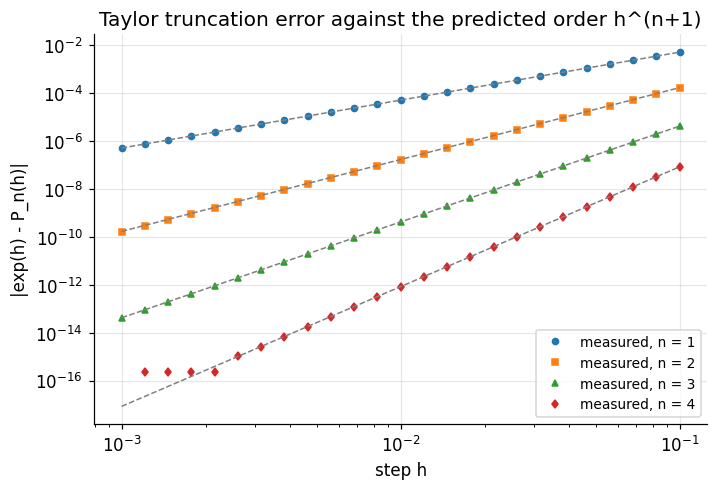

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for n, marker in zip((1, 2, 3, 4), ("o", "s", "^", "d")):
    errs = np.abs(np.exp(hs) - maclaurin(exp_d, n, hs))
    ax.loglog(hs, errs, marker, ms=4, label=f"measured, n = {n}")
    ref = errs[-1] * (hs / hs[-1]) ** (n + 1)
    ax.loglog(hs, ref, lw=1.0, ls="--", color="0.5")
ax.set_xlabel("step h")
ax.set_ylabel("|exp(h) - P_n(h)|")
ax.set_title("Taylor truncation error against the predicted order h^(n+1)")
ax.legend(fontsize=9, loc="lower right")
plt.show()

Each point cloud lies on its dashed reference line of slope $n+1$ over five decades of error.
The slopes, not the offsets, are what Theorem 4.2 predicts; the offsets carry the constant
$\sup \lvert f^{(n+1)} \rvert / (n+1)!$.

### 7.3 Three counterexamples

Each cell block below removes one hypothesis and shows the breakage.

1. **Theorem 4.2 needs $f$ real-valued.** For $f(t) = e^{it}$ on $[0, 2\pi]$ there is no
   $c$ with $f(2\pi) - f(0) = f'(c)(2\pi - 0)$, because the left side is $0$ and
   $\lvert f'(c) \rvert = 1$.
2. **Theorem 4.7 excludes the endpoint.** $\sum_n x^n/n$ converges at $x = -1$; its
   term-by-term derivative $\sum_n x^{n-1}$ does not.
3. **Proposition 4.10 blocks the converse of Theorem 4.7.** For $e^{-1/x^2}$ the Taylor series
   converges everywhere and the remainder never decreases.

In [9]:
# --- (1) the mean value theorem fails for complex-valued f ---------------
print("counterexample 1: Lagrange remainder needs a real-valued f")
f_c = lambda t: np.exp(1j * t)
lhs = f_c(2 * np.pi) - f_c(0.0)
cs = np.linspace(0.0, 2 * np.pi, 100001)
best = np.min(np.abs(1j * np.exp(1j * cs) * 2 * np.pi - lhs))
print(f"  f(2pi) - f(0)                    = {lhs:.3e}")
print(f"  min over c of |f'(c)(2pi) - 0|   = {best:.6f}   (never 0: |f'| = 1 always)")
assert abs(lhs) < 1e-12 and best > 6.0

# --- (2) term-by-term differentiation fails at the endpoint --------------
print("\ncounterexample 2: Theorem 4.7 holds only strictly inside the interval")
for x, label in [(-0.999, "inside"), (-1.0, "endpoint")]:
    n = np.arange(1, 200001)
    series = float(np.sum(x ** n / n))
    deriv = float(np.sum(x ** (n - 1)))
    print(f"  x = {x:7.3f} ({label:8s}): sum x^n/n = {series:12.6f}"
          f"    sum x^(n-1) partial = {deriv:12.6f}")
n = np.arange(1, 21)
print("  partial sums of the derivative series at x = -1:", np.cumsum((-1.0) ** (n - 1))[:8],
      "... oscillates forever")
assert abs(float(np.sum((-1.0) ** np.arange(1, 200001) / np.arange(1, 200001))) + np.log(2)) < 1e-5

# --- (3) smooth but not analytic ----------------------------------------
print("\ncounterexample 3: a convergent Taylor series that converges to the wrong function")
for x in (0.5, 0.3, 0.1):
    print(f"  x = {x}: f(x) = {f_flat(np.array([x]))[0]:.6e}   Taylor sum = 0.0"
          f"   |R_n(x)| = {f_flat(np.array([x]))[0]:.6e} for every n")
assert f_flat(np.array([0.5]))[0] > 0.018

counterexample 1: Lagrange remainder needs a real-valued f
  f(2pi) - f(0)                    = 0.000e+00-2.449e-16j
  min over c of |f'(c)(2pi) - 0|   = 6.283185   (never 0: |f'| = 1 always)

counterexample 2: Theorem 4.7 holds only strictly inside the interval
  x =  -0.999 (inside  ): sum x^n/n =    -0.692647    sum x^(n-1) partial =     0.500250
  x =  -1.000 (endpoint): sum x^n/n =    -0.693145    sum x^(n-1) partial =     0.000000
  partial sums of the derivative series at x = -1: [1. 0. 1. 0. 1. 0. 1. 0.] ... oscillates forever

counterexample 3: a convergent Taylor series that converges to the wrong function
  x = 0.5: f(x) = 1.831564e-02   Taylor sum = 0.0   |R_n(x)| = 1.831564e-02 for every n
  x = 0.3: f(x) = 1.494534e-05   Taylor sum = 0.0   |R_n(x)| = 1.494534e-05 for every n
  x = 0.1: f(x) = 3.720076e-44   Taylor sum = 0.0   |R_n(x)| = 3.720076e-44 for every n


The first block shows the true obstruction: the chord of $e^{it}$ over a full period is the zero
vector, while every tangent has length $1$, so no intermediate point can reproduce the chord.
Complex- and vector-valued functions must use the integral remainder of Theorem 4.1.

The second block shows $\sum x^n/n$ converging to $-\ln 2 = -0.693$ at $x = -1$ while its formal
derivative $\sum x^{n-1}$ oscillates between $1$ and $0$ forever. The strict inequality
$\lvert x - a \rvert \lt R$ in Theorem 4.7 is load-bearing.

The third block is Proposition 4.10 numerically: $\lvert R_n(0.5) \rvert = 1.83 \times 10^{-2}$
whatever $n$ is.

### 7.4 Hand-rolled series evaluation against the library

The cell implements $\exp$ and $\arctan$ from their Maclaurin series — with Horner's rule for the
polynomial evaluation — and compares against `numpy`. It also shows the catastrophic cancellation
that follows from feeding a large negative argument to the alternating $\exp$ series, and the
standard cure.

In [10]:
def horner(coeffs, x):
    """Evaluate sum coeffs[k] x^k with n multiplications and n additions."""
    acc = 0.0
    for c in reversed(coeffs):
        acc = acc * x + c
    return acc


def exp_series(x, n_terms=30):
    return horner([1.0 / factorial(k) for k in range(n_terms)], x)


def arctan_series(x, n_terms=60):
    coeffs = []
    for k in range(2 * n_terms):
        coeffs.append(0.0 if k % 2 == 0 else (-1.0) ** ((k - 1) // 2) / k)
    return horner(coeffs, x)


print("hand-rolled versus numpy")
print(f"{'x':>7s} {'exp_series':>18s} {'np.exp':>18s} {'rel. error':>12s}")
for x in (-1.0, 0.25, 1.0, 2.0):
    mine, lib = exp_series(x), float(np.exp(x))
    print(f"{x:7.2f} {mine:18.14f} {lib:18.14f} {abs(mine-lib)/abs(lib):12.3e}")
    assert abs(mine - lib) / abs(lib) < 1e-14

print(f"\n{'x':>7s} {'arctan_series':>18s} {'np.arctan':>18s} {'rel. error':>12s}")
for x in (0.1, 0.3, 0.5):
    mine, lib = arctan_series(x), float(np.arctan(x))
    print(f"{x:7.2f} {mine:18.14f} {lib:18.14f} {abs(mine-lib)/abs(lib):12.3e}")
    assert abs(mine - lib) / abs(lib) < 1e-14

def exp_series_naive(x, n_terms=120):
    """Term-by-term summation, returning the sum and the largest term seen."""
    terms = [x ** k / factorial(k) for k in range(n_terms)]
    return sum(terms), max(abs(t) for t in terms)


print("\ncatastrophic cancellation in the alternating exp series")
print(f"{'x':>7s} {'direct sum':>16s} {'largest term':>16s} {'1/series(-x)':>16s}"
      f" {'np.exp':>16s} {'direct rel.err':>15s}")
for x in (-10.0, -20.0, -30.0):
    direct, biggest = exp_series_naive(x)
    safe = 1.0 / exp_series_naive(-x)[0]
    lib = float(np.exp(x))
    print(f"{x:7.1f} {direct:16.6e} {biggest:16.6e} {safe:16.6e} {lib:16.6e}"
          f" {abs(direct - lib) / lib:15.3e}")
    assert abs(safe - lib) / lib < 1e-14

bad_sum = exp_series_naive(-30.0)[0]
assert abs(bad_sum - np.exp(-30.0)) / np.exp(-30.0) > 1.0

hand-rolled versus numpy
      x         exp_series             np.exp   rel. error
  -1.00   0.36787944117144   0.36787944117144    0.000e+00
   0.25   1.28402541668774   1.28402541668774    0.000e+00
   1.00   2.71828182845905   2.71828182845905    0.000e+00
   2.00   7.38905609893065   7.38905609893065    0.000e+00

      x      arctan_series          np.arctan   rel. error
   0.10   0.09966865249116   0.09966865249116    1.392e-16
   0.30   0.29145679447787   0.29145679447787    1.905e-16
   0.50   0.46364760900081   0.46364760900081    1.197e-16

catastrophic cancellation in the alternating exp series
      x       direct sum     largest term     1/series(-x)           np.exp  direct rel.err
  -10.0     4.539993e-05     2.755732e+03     4.539993e-05     4.539993e-05       9.122e-09
  -20.0     1.477087e-09     4.309980e+07     2.061154e-09     2.061154e-09       2.834e-01
  -30.0    -6.592959e-05     7.762070e+11     9.357623e-14     9.357623e-14       7.046e+08


Both hand-rolled evaluators agree with `numpy` to relative error below $10^{-14}$ inside the
radius of convergence — two independent routes to the same digits.

The cancellation table is the reason the series is never used directly for negative arguments.
At $x = -30$ the individual terms reach magnitude $7.8 \times 10^{11}$ while the answer is
$9.4 \times 10^{-14}$, so about $25$ decimal digits must cancel and only $16$ are available: the
direct sum comes out **negative**, with relative error $7 \times 10^{8}$.

Summing the all-positive series at $-x$ and taking a reciprocal has no cancellation at all and is
exact to one machine epsilon. Same mathematics, different arithmetic.

### 7.5 The radius is set by the nearest complex singularity

Cauchy-Hadamard is a statement about coefficients, but for a function with a complex
continuation it has a geometric reading: the radius of the Taylor series at $a$ equals the
distance from $a$ to the nearest singularity of the complex extension.

The cell expands $1/(1+z^2)$, whose only singularities are the poles $\pm i$, about the three
centres $a = 0$, $a = 1$ and $a = 2$, measures $\lvert a_n \rvert^{-1/n}$, and draws the
predicted discs.

 centre a    limsup |a_n|^(1/n)    R = 1/limsup   distance to +/- i
     0.00          1.0000000000    1.0000000000        1.0000000000
     1.00          0.7064897595    1.4154486835        1.4142135624
     2.00          0.4462852905    2.2407191570        2.2360679775


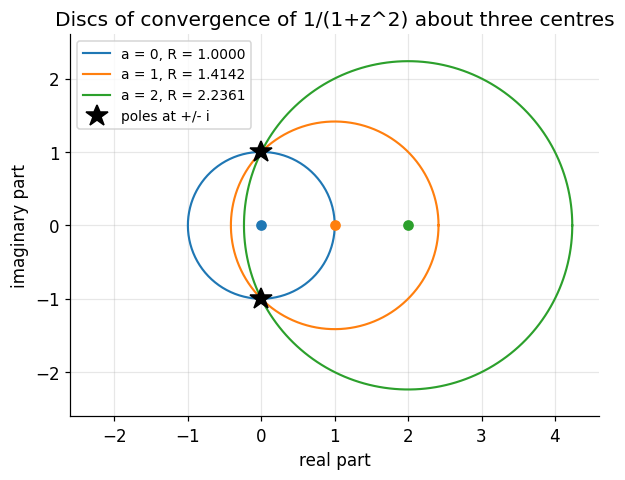

In [11]:
def taylor_coeffs_inv_1pz2(a, N):
    """Taylor coefficients of 1/(1+z^2) about a, from the partial-fraction form."""
    # 1/(1+z^2) = (1/(2i)) [ 1/(z-i) - 1/(z+i) ]; expand each geometric series about a.
    c = np.zeros(N, dtype=complex)
    for n in range(N):
        c[n] = (1 / (2j)) * (-1.0 / (a - 1j) ** (n + 1) + 1.0 / (a + 1j) ** (n + 1))
    return c


print(f"{'centre a':>9s} {'limsup |a_n|^(1/n)':>21s} {'R = 1/limsup':>15s}"
      f" {'distance to +/- i':>19s}")
centres = [0.0, 1.0, 2.0]
for a in centres:
    c = taylor_coeffs_inv_1pz2(a, 400)
    ns = np.arange(200, 400)
    roots_tail = np.abs(c[200:400]) ** (1.0 / ns)
    L = float(roots_tail.max())               # limsup, estimated on the tail
    meas = 1.0 / L
    dist = float(np.hypot(a, 1.0))
    print(f"{a:9.2f} {L:21.10f} {meas:15.10f} {dist:19.10f}")
    assert abs(meas - dist) < 5e-3

fig, ax = plt.subplots(figsize=(6.2, 6.2))
theta = np.linspace(0.0, 2 * np.pi, 400)
for a, colour in zip(centres, ("C0", "C1", "C2")):
    Rr = np.hypot(a, 1.0)
    ax.plot(a + Rr * np.cos(theta), Rr * np.sin(theta), color=colour, lw=1.4,
            label=f"a = {a:.0f}, R = {Rr:.4f}")
    ax.plot([a], [0.0], marker="o", color=colour, ms=6)
ax.plot([0.0, 0.0], [1.0, -1.0], "k*", ms=15, label="poles at +/- i")
ax.set_aspect("equal")
ax.set_xlim(-2.6, 4.6)
ax.set_ylim(-2.6, 2.6)
ax.set_xlabel("real part")
ax.set_ylabel("imaginary part")
ax.set_title("Discs of convergence of 1/(1+z^2) about three centres")
ax.legend(fontsize=9, loc="upper left")
plt.show()

The measured $1/\limsup_n \lvert a_n \rvert^{1/n}$ equals the distance to the poles in all three
cases: $1.0000$ against $1$, $1.4154$ against $\sqrt{2} = 1.4142$, and $2.2407$ against
$\sqrt{5} = 2.2361$. The tiny excess is the finite-$n$ truncation of a limit superior, and it
shrinks as the tail index grows.

Each circle just touches a pole, and no circle contains one. That is the geometry hidden inside
Theorem 4.5: on the real line nothing at all happens at $x = \pm 1$, but the series stops there,
because the disc has run into $\pm i$.

### 7.6 Where the three remainder forms disagree: the binomial series near $x = -1$

The Lagrange bound for $(1+x)^{1/2}$ contains $(1+c)^{1/2 - n - 1}$, which blows up as
$c \to -1$; the Cauchy form contains $\bigl((x-c)/(1+c)\bigr)^n$, which stays below
$\lvert x \rvert^n$. The cell measures both against the true error at $x = -0.9$.

In [12]:
alpha = 0.5
x = -0.9
true_val = (1 + x) ** alpha


def binom_coeff(alpha, n):
    out = 1.0
    for j in range(n):
        out *= (alpha - j) / (j + 1)
    return out


print(f"{'n':>4s} {'|R_n| true':>14s} {'Lagrange bound':>18s} {'Cauchy bound':>16s}")
for n in (2, 4, 8, 16, 32):
    Pn = sum(binom_coeff(alpha, k) * x ** k for k in range(n + 1))
    Rn = abs(true_val - Pn)
    # Lagrange: sup over c in (x,0) of |f^(n+1)(c)| / (n+1)! * |x|^(n+1); worst c -> x
    lag = abs(binom_coeff(alpha, n + 1)) * (1 + x) ** (alpha - n - 1) * abs(x) ** (n + 1)
    # Cauchy: (n+1)|C(alpha,n+1)| * max(1,(1+x)^(alpha-1)) * |x|^(n+1)
    cau = (n + 1) * abs(binom_coeff(alpha, n + 1)) * max(1.0, (1 + x) ** (alpha - 1)) * abs(x) ** (n + 1)
    print(f"{n:4d} {Rn:14.3e} {lag:18.3e} {cau:16.3e}")

n = 32
Pn = sum(binom_coeff(alpha, k) * x ** k for k in range(n + 1))
lag32 = abs(binom_coeff(alpha, n + 1)) * (1 + x) ** (alpha - n - 1) * abs(x) ** (n + 1)
cau32 = (n + 1) * abs(binom_coeff(alpha, n + 1)) * max(1.0, (1 + x) ** (alpha - 1)) * abs(x) ** (n + 1)
assert abs(true_val - Pn) < cau32 < lag32
print("\nat n = 32 the Cauchy bound is finite and correct while the Lagrange bound has diverged")

   n     |R_n| true     Lagrange bound     Cauchy bound
   2      1.325e-01          1.441e+01        4.322e-01
   4      6.133e-02          5.106e+02        2.553e-01
   8      2.094e-02          1.337e+06        1.203e-01
  16      4.286e-03          2.171e+13        3.690e-02
  32      3.471e-04          1.471e+28        4.854e-03

at n = 32 the Cauchy bound is finite and correct while the Lagrange bound has diverged


The true error falls steadily. The Cauchy bound falls with it and stays a valid upper bound at
every $n$; the Lagrange bound grows without limit, because $(1+c)^{-n-1/2}$ with $c$ allowed
down to $-0.9$ overwhelms $\lvert x \rvert^{n+1}$.

This is the practical reason Theorem 4.3 exists. Two theorems with identical hypotheses can have
wildly different usefulness on the same problem.

## 8. Applications

### 8.1 Physics: every stable equilibrium is a harmonic oscillator

Let $V$ be a smooth potential with a stable equilibrium at $x_0$, so $V'(x_0) = 0$ and
$V''(x_0) \gt 0$. Theorem 4.4 with $n = 2$ gives

$$
V(x) = V(x_0) + \tfrac12 V''(x_0)(x-x_0)^2 + o\bigl((x-x_0)^2\bigr) .
$$

The linear term is absent by stationarity, so to leading order the restoring force is
$-V''(x_0)(x-x_0)$ and the small-oscillation frequency is $\omega = \sqrt{V''(x_0)/m}$.

The next term controls the failure of that picture. For the pendulum,
$V(\theta) = mgl(1-\cos\theta) = mgl(\theta^2/2 - \theta^4/24 + O(\theta^6))$, and the negative
quartic term makes the period grow with amplitude: $T/T_0 = 1 + \theta_0^2/16 + O(\theta_0^4)$,
derived in Exercise L2.2.

### 8.2 Physics: relativity contains Newtonian mechanics

Expanding $\gamma = (1-\beta^2)^{-1/2}$ by the binomial series in $\beta = v/c$,

$$
E = \gamma m c^2 = mc^2 + \tfrac12 m v^2 + \tfrac38 m \frac{v^4}{c^2} + O(\beta^6) .
$$

Newtonian kinetic energy is the degree-$2$ Taylor coefficient of the relativistic one, and the
relative error of the Newtonian formula is $\tfrac34\beta^2$ — computed in Exercise L2.1.

### 8.3 Machine learning: second-order local models

For a twice-differentiable loss $L$ on $\mathbb{R}^d$, the multivariable form of Theorem 4.4 at
$w_0$ reads

$$
L(w_0 + \Delta) = L(w_0) + \nabla L(w_0)^{\top}\Delta + \tfrac12 \Delta^{\top} H \Delta + o(\lVert \Delta \rVert^2),
\qquad H = \nabla^2 L(w_0) .
$$

Minimising the quadratic part gives the Newton step $\Delta^{\ast} = -H^{-1}\nabla L(w_0)$, and
the $o(\lVert \Delta \rVert^2)$ term is precisely why Newton's method is only locally convergent.

The same expansion is the reason KL divergence is locally a quadratic form in the Fisher
information matrix, worked out in Exercise L2.9, and the reason activation functions are
characterised near the origin by their first few coefficients, in Exercises L2.3 and L2.11.

### 8.4 Numerical analysis: step-size selection

Subtracting the expansions of $f(x \pm h)$ gives

$$
\frac{f(x+h) - f(x-h)}{2h} = f'(x) + \frac{h^2}{6}f'''(x) + O(h^4) ,
$$

so the truncation error is $O(h^2)$ while the round-off error grows like $\varepsilon/h$. The
total is minimised at $h^{\ast} \asymp \varepsilon^{1/3}$ — Exercise L2.12 does the optimisation,
and the cell below measures it.

In [13]:
f_test = np.sin
fp_true = np.cos(1.0)
hs2 = np.logspace(-12.0, -1.0, 120)
errs = np.abs((f_test(1.0 + hs2) - f_test(1.0 - hs2)) / (2 * hs2) - fp_true)
h_best = hs2[int(np.argmin(errs))]
h_pred = (3 * EPS / abs(np.sin(1.0))) ** (1 / 3)

print("central difference for cos(1) = f'(1), f = sin")
print(f"  measured optimal h  = {h_best:.4e}")
print(f"  predicted (3 eps / |f'''|)^(1/3) = {h_pred:.4e}")
print(f"  ratio measured / predicted       = {h_best / h_pred:.4f}")
print(f"  smallest achievable error        = {errs.min():.4e}")
print(f"  error at h = 1e-10 (round-off dominated) = "
      f"{abs((f_test(1.0 + 1e-10) - f_test(1.0 - 1e-10)) / 2e-10 - fp_true):.4e}")
assert 0.2 < h_best / h_pred < 5.0

central difference for cos(1) = f'(1), f = sin
  measured optimal h  = 6.9237e-06
  predicted (3 eps / |f'''|)^(1/3) = 9.2507e-06
  ratio measured / predicted       = 0.7484
  smallest achievable error        = 2.5591e-13
  error at h = 1e-10 (round-off dominated) = 5.8481e-08


The measured optimum $h = 6.9 \times 10^{-6}$ sits within a factor of $1.4$ of the predicted
$(3\varepsilon / \lvert f''' \rvert)^{1/3} = 9.3 \times 10^{-6}$, and the error at
$h = 10^{-10}$ is $2 \times 10^{5}$ times worse than at the optimum. Taking $h$ "as small as
possible" is the wrong instinct, and Taylor's theorem is what says how small is small enough.

## 9. Key Takeaways

- **One theorem, four remainders.** $f = P_n + R_n$ always; the integral form (Theorem 4.1) is
  exact and needs $f^{(n+1)}$ continuous, Lagrange and Cauchy (Theorems 4.2, 4.3) need only
  $f^{(n+1)}$ to exist on the open interval, and Peano (Theorem 4.4) needs only $f^{(n)}(a)$ but
  gives no numerical bound.

- **Lagrange needs a real-valued $f$.** Its proof is a mean value theorem, and Section 7.3 runs
  the complex-valued function for which no intermediate point exists.

- **The radius is a $\limsup$, not a limit.** $R = 1/\limsup_n \lvert a_n \rvert^{1/n}$ always
  (Theorem 4.5); the ratio test is a special case that fails on the lacunary series of
  Example 6.3.

- **Inside the radius a power series is a $C^{\infty}$ function and may be differentiated and
  integrated term by term** (Theorem 4.7). The proof is uniform convergence on compact
  subintervals plus the fundamental theorem of calculus, and both the words *compact* and
  *uniform* are necessary.

- **The coefficients are unique** and equal $f^{(n)}(a)/n!$ (Corollary 4.8), so any route to a
  convergent power series has produced the Taylor series.

- **Endpoints are a separate theorem.** Abel's theorem (Theorem 4.9) recovers the endpoint value
  when the numerical series converges, and gives $\pi/4$ and $\ln 2$; nothing about the interior
  implies it.

- **Smooth does not imply analytic.** $e^{-1/x^2}$ is $C^{\infty}$ with every derivative zero at
  the origin (Proposition 4.10), and by Borel's theorem (Theorem 4.11) that is the generic
  situation, not a curiosity.

- **The geometry is complex even when the function is real.** The radius equals the distance from
  the centre to the nearest singularity of the complex continuation, measured in Section 7.5 for
  $1/(1+z^2)$ about three different centres.

## 10. References

**Textbooks.**

- Rudin, W. *Principles of Mathematical Analysis*, 3rd ed. — Taylor's theorem with Lagrange
  remainder (Theorem 5.15); the root-test radius (Theorem 3.39); the Weierstrass M-test
  (Theorem 7.10), continuity of a uniform limit (Theorem 7.12), integration (Theorem 7.16) and
  differentiation (Theorem 7.17) of uniformly convergent sequences; power series (Theorem 8.1);
  Abel's theorem (Theorem 8.2); the function $e^{-1/x^2}$ (Chapter 8, Exercise 1).
- Spivak, M. *Calculus*, 4th ed. — Chapter 20 (approximation by polynomial functions, the three
  remainder forms), Chapter 24 (uniform convergence and power series), Chapter 27 (complex power
  series and Euler's formula).
- Apostol, T. M. *Calculus, Vol. I*, 2nd ed. — Chapter 7 (Taylor's formula with remainder,
  including the integral form), Chapter 11 (sequences and series of functions, power series,
  Abel's theorem).
- Bender, C. M. and Orszag, S. A. *Advanced Mathematical Methods for Scientists and Engineers* —
  section 3.4 (the symbols $O$, $o$ and $\sim$), section 6.4 (Laplace's method), section 7.2
  (perturbation series for algebraic equations).
- Hörmander, L. *The Analysis of Linear Partial Differential Operators I*, 2nd ed.,
  Theorem 1.2.6 — Borel's theorem, cited in Theorem 4.11.
- Trefethen, L. N. *Approximation Theory and Approximation Practice*, Chapters 3 and 8 — why the
  radius of convergence is the wrong quantity for approximation on an interval, and what replaces
  it.

**Within this repository.**

- Prerequisites and downstream modules: [the module graph](../../docs/prerequisites.md).
- Symbol conventions, including the ruling $P_n$ over $T_n$:
  [the notation register](../../docs/notation.md).
- Differentiation rules used throughout:
  [Module 03 — Single-Variable Derivatives](../03_single_variable_derivatives/).
- Convergence tests, including the root and ratio tests used in Proof 5.5:
  [Module 08 — Sequences, Series and Convergence](../08_sequences_series_convergence/).
- Practice problems for this module: [exercises.ipynb](exercises.ipynb).